# Hour 2 · Notebook 2. Masked Prediction: MAE on EuroSAT

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Filled notebook:**
[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lstival/ssl_tutorial_sibgrapi2026/blob/main/notebooks/remote_sensing/02_masking_mae.ipynb)
**Pretrained checkpoints:**
[![GitHub Releases](https://img.shields.io/static/v1.svg?logo=github&label=Repo&message=Checkpoints&color=lightgrey)](https://github.com/lstival/ssl_tutorial_sibgrapi2026/releases)

**Tutorial:** SIBGRAPI 2026: *Self-Supervised Learning: Contrastive, Masking, and Distillation Methods*
**Segment:** 2.3. Generative masking (slides 37-41) · Instantiates Hour 1, Section 1.5 · Figure 2B

---

**Mechanism: masked prediction.** Unlike the contrastive mechanism in Notebook 1, MAE
(Masked Autoencoder) needs **no negatives at all**. There is nothing to push apart, so
representation collapse (everything mapping to the same point) is not prevented by a
repulsive term. Instead, collapse is avoided structurally: the pretext task (reconstruct
what's missing) is only solvable if the visible patches carry real information about the
missing ones.

The recipe:

1. **Patchify** the image into a grid of non-overlapping patches (our ViT-S/8 grid: 8x8 = 64 patches).
2. **Mask** a large fraction (60-75%) of patches at random. MAE's masking ratio is much
   higher than e.g. BERT's ~15%, because images are spatially redundant: a small mask ratio
   makes reconstruction solvable by simple interpolation, which teaches nothing useful (we'll
   see this failure mode directly at the end of this notebook).
3. Encode **only the visible patches** with the ViT encoder (an asymmetric design: most of
   the compute goes to a small fraction of the image).
4. A **lightweight decoder** takes the encoded visible tokens plus learnable mask tokens
   (placed back at masked positions) and reconstructs pixel values.
5. Compute the reconstruction loss **only at masked positions**, so the model is never
   rewarded for copying visible pixels.

In [1]:
## Standard libraries
import os
import urllib.request

## Imports for plotting
import matplotlib.pyplot as plt
import numpy as np

## tqdm for loading bars
from tqdm.auto import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
import torchvision
from torchvision import transforms

%matplotlib inline

c:\Users\stiva\anaconda3\envs\bepe\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Make the shared tutorial module importable.
# Local clone: it lives in src/remote_sensing/. Colab: download it next to this notebook.
import os, sys, urllib.request

_LOCAL_SRC = os.path.join("..", "..", "src", "remote_sensing")
if os.path.isfile(os.path.join(_LOCAL_SRC, "tutorial_rs.py")):
    sys.path.insert(0, _LOCAL_SRC)
elif not os.path.isfile("tutorial_rs.py"):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lstival/ssl_tutorial_sibgrapi2026/main/src/remote_sensing/tutorial_rs.py", "tutorial_rs.py")

from tutorial_rs import (
    seed_everything, get_device, setup_plotting,
    EUROSAT_CLASSES, EUROSAT_MEAN, EUROSAT_STD, IMG_SIZE,
    load_eurosat, stratified_split, build_eval_transform, denormalize,
    build_vit_s8, try_load_checkpoint, show_image_grid, plot_curve,
)

setup_plotting()
seed_everything(42)
device = get_device()
print("Device:", device)

DATASET_PATH = "../../data"
CHECKPOINT_PATH = "../../artifacts/remote_sensing/checkpoints"

# On Colab, each notebook opened via File > Open notebook > GitHub gets its own fresh VM: a
# checkpoint saved -- or dataset downloaded -- by this notebook is invisible to another
# notebook opened separately, only to cells further down in *this* notebook. Mounting Drive
# repoints both paths at a folder that survives across notebooks and across sessions, so e.g.
# a checkpoint trained live here is still there when 04_comparative_evaluation runs later, and
# the dataset download only happens once across the whole tutorial.
# Flip USE_DRIVE_FOR_TUTORIAL_DATA to False to keep everything local to this VM instead (e.g.
# to skip the Drive permission prompt, at the cost of losing state between notebooks).
USE_DRIVE_FOR_TUTORIAL_DATA = True
if USE_DRIVE_FOR_TUTORIAL_DATA and "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    _drive_root = "/content/drive/MyDrive/ssl_tutorial_sibgrapi2026/remote_sensing"
    CHECKPOINT_PATH = _drive_root + "/checkpoints"
    DATASET_PATH = _drive_root + "/data"
    os.makedirs(CHECKPOINT_PATH, exist_ok=True)
    os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

PATCH_SIZE = 8
GRID_SIZE = IMG_SIZE // PATCH_SIZE  # 8
NUM_PATCHES = GRID_SIZE * GRID_SIZE  # 64

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

Device: cuda:0


<Figure size 640x480 with 0 Axes>

In [ ]:
# --- Check that the pretrained encoders are reachable -------------------------------
# Weights are published on a GitHub Release. Locally they are already on disk once fetched; on Colab they
# are downloaded on demand. This cell just reports what is available, so a missing or
# mis-served checkpoint shows up here rather than halfway through training below.
import os, urllib.request, urllib.error

_CKPTS = ["contrastive_vit_s8.pt", "mae_vit_s8.pt", "dino_vit_s8.pt", "random_init_vit_s8.pt"]
_REPO = "lstival/ssl_tutorial_sibgrapi2026"
_MEDIA = f"https://github.com/{_REPO}/releases/download/weights-v1/"

for _name in _CKPTS:
    _local = os.path.join(CHECKPOINT_PATH, _name)
    _repo_copy = os.path.join("..", "..", "artifacts", "remote_sensing", "checkpoints", _name)
    _found = next((p for p in (_local, _repo_copy) if os.path.isfile(p)), None)
    if _found and os.path.getsize(_found) > 1024:
        print(f"  on disk    {_name:<26} {os.path.getsize(_found)/1048576:.1f} MB")
        continue
    try:
        _req = urllib.request.Request(_MEDIA + _name, method="HEAD")
        with urllib.request.urlopen(_req, timeout=20) as _r:
            _mb = int(_r.headers.get("Content-Length") or 0) / 1048576
        print(f"  downloadable {_name:<24} {_mb:.1f} MB")
    except Exception as _e:
        print(f"  UNAVAILABLE  {_name:<24} {_e} -> this notebook will train live instead")


## Data and patchify

We reuse the deterministic (non-augmented) eval transform here: MAE's pretext task supplies
its own difficulty via masking, so unlike SimCLR we don't need aggressive data augmentation
on top.

In [3]:
eval_transform = build_eval_transform(img_size=IMG_SIZE, mean=EUROSAT_MEAN, std=EUROSAT_STD)
full_dataset = load_eurosat(DATASET_PATH, transform=eval_transform)
train_idx, test_idx = stratified_split(full_dataset, test_size=0.2, seed=42)

train_subset = data.Subset(full_dataset, train_idx)
train_loader = data.DataLoader(train_subset, batch_size=256, shuffle=True, drop_last=True, num_workers=0, pin_memory=True)
print(f"MAE training pool: {len(train_subset)} images (labels discarded)")

MAE training pool: 21600 images (labels discarded)


In [4]:
def patchify(imgs, patch_size=PATCH_SIZE):
    '''(B, C, H, W) -> (B, num_patches, patch_size*patch_size*C)'''
    B, C, H, W = imgs.shape
    grid = H // patch_size
    x = imgs.reshape(B, C, grid, patch_size, grid, patch_size)
    x = x.permute(0, 2, 4, 3, 5, 1)  # (B, grid, grid, patch, patch, C)
    x = x.reshape(B, grid * grid, patch_size * patch_size * C)
    return x


def unpatchify(patches, patch_size=PATCH_SIZE, img_size=IMG_SIZE, channels=3):
    '''Inverse of patchify: (B, num_patches, patch_size*patch_size*C) -> (B, C, H, W)'''
    B, N, _ = patches.shape
    grid = img_size // patch_size
    x = patches.reshape(B, grid, grid, patch_size, patch_size, channels)
    x = x.permute(0, 5, 1, 3, 2, 4)  # (B, C, grid, patch, grid, patch)
    x = x.reshape(B, channels, img_size, img_size)
    return x

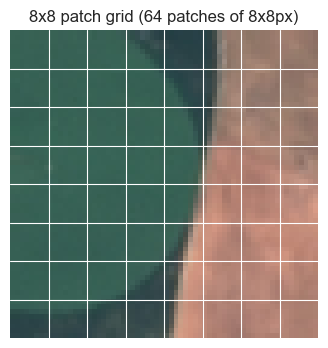

Round-trip max abs error: 0.0


In [5]:
# Visualize the patch grid overlaid on one EuroSAT patch
sample_img, _ = full_dataset[train_idx[0]]
sample_disp = denormalize(sample_img, EUROSAT_MEAN, EUROSAT_STD).permute(1, 2, 0).numpy()

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(sample_disp)
for k in range(1, GRID_SIZE):
    ax.axhline(k * PATCH_SIZE - 0.5, color="white", linewidth=0.8)
    ax.axvline(k * PATCH_SIZE - 0.5, color="white", linewidth=0.8)
ax.set_title(f"{GRID_SIZE}x{GRID_SIZE} patch grid ({NUM_PATCHES} patches of {PATCH_SIZE}x{PATCH_SIZE}px)")
ax.axis("off")
plt.show()
plt.close()

# Sanity check patchify/unpatchify round-trip
patches = patchify(sample_img.unsqueeze(0))
recon = unpatchify(patches)
print("Round-trip max abs error:", (recon - sample_img.unsqueeze(0)).abs().max().item())

## Random masking

`random_masking` takes patch embeddings `x` of shape `(B, N, D)` and a `mask_ratio`, and
decides **which patches stay visible** and which are masked, independently per image in the
batch.

The standard MAE trick is to generate random noise per patch, `argsort` it to get a random
permutation, keep the first `len_keep = N * (1 - mask_ratio)` indices as visible, and record
`ids_restore` so the decoder can later put mask tokens back in their original positions.

<div class="alert alert-info">

**Why the double argsort:** `ids_shuffle = noise.argsort(dim=1)` is a random permutation of
patch indices, and `ids_restore = ids_shuffle.argsort(dim=1)` is its inverse, so gathering
with `ids_restore` undoes the shuffle exactly. `torch.gather` with `ids_shuffle[:, :len_keep]`
then selects the visible patches. Sorting noise is a cheap way to draw a different random
subset for every image in the batch with no Python-level loop.

</div>

In [6]:
def random_masking(x, mask_ratio):
    '''
    x: (B, N, D) patch embeddings (pre pos-embed, pre [CLS]).
    Returns:
      x_visible: (B, len_keep, D), only the visible (unmasked) patches
      mask: (B, N), 0 for visible, 1 for masked (in ORIGINAL patch order)
      ids_restore: (B, N), permutation that restores original patch order
      ids_keep: (B, len_keep), original patch index of each visible token, in x_visible order
    '''
    B, N, D = x.shape
    len_keep = int(N * (1 - mask_ratio))

    noise = torch.rand(B, N, device=x.device)  # random score per patch

    ids_shuffle = torch.argsort(noise, dim=1)       # ascending: small noise = keep
    ids_restore = torch.argsort(ids_shuffle, dim=1)  # inverse permutation

    ids_keep = ids_shuffle[:, :len_keep]
    x_visible = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).expand(-1, -1, D))

    mask = torch.ones(B, N, device=x.device)
    mask[:, :len_keep] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)  # unshuffle to original order

    # ids_keep carries the true original position of each visible token (in x_visible's order),
    # which forward_encoder needs to add the correct positional embedding to each one.
    return x_visible, mask, ids_restore, ids_keep


# Quick sanity check with a random tensor
_x = torch.randn(2, 64, 8)
_vis, _mask, _restore, _keep = random_masking(_x, mask_ratio=0.75)
print("visible shape:", _vis.shape, "| expected:", (2, 16, 8))
print("mask ratio:", _mask.mean().item(), "| expected ~0.75")

visible shape: torch.Size([2, 16, 8]) | expected: (2, 16, 8)
mask ratio: 0.75 | expected ~0.75


### What the mask actually looks like

`random_masking` returned only tensors, so before wiring it into the model, let's see it act
on a real EuroSAT image. We patchify one image, run `random_masking` at
`mask_ratio = 0.75`, and draw two panels:

- **Left:** every patch labeled with its original id (0-63, row-major). Green ids are the
  ~16 that stay visible; red ids are the 48 about to be masked.
- **Right:** the encoder's actual input. Visible patches keep their pixels; each masked patch
  is overwritten with random noise and marked `?`. The noise makes the point concrete: the
  encoder sees *nothing* about content at those positions, only that a slot exists there
  (the positional embedding). Reconstructing those `?` slots is the entire pretext task.


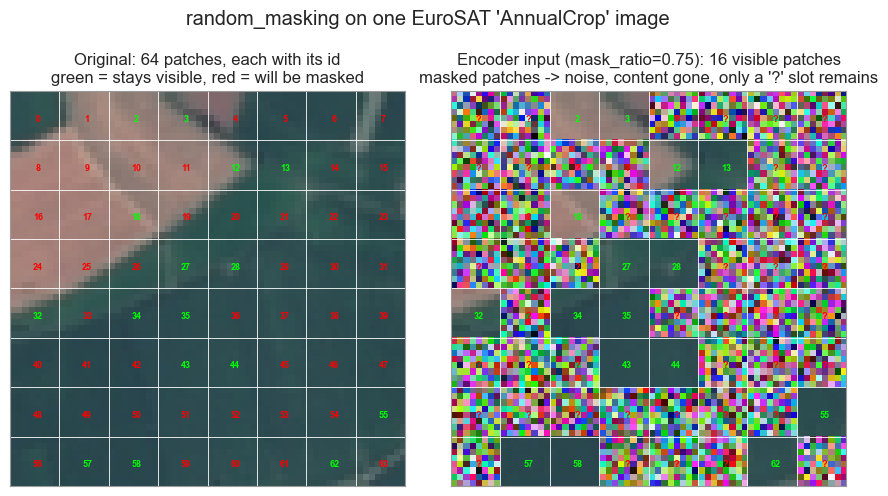

visible patch ids: [2, 3, 12, 13, 18, 27, 28, 32, 34, 35, 43, 44, 55, 57, 58, 62]
masked patch ids : [0, 1, 4, 5, 6, 7, 8, 9, 10, 11, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26, 29, 30, 31, 33, 36, 37, 38, 39, 40, 41, 42, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 56, 59, 60, 61, 63]
kept 16/64 patches  ->  mask ratio 0.75


In [7]:
# Visual example: what random_masking does to a real EuroSAT image.
#
# We patchify one EuroSAT image, run random_masking on the patch grid, and show two panels:
#   Left  - the original image with every patch numbered by its ORIGINAL id (0..63, row-major).
#           Green id = this patch will stay visible; red id = this patch will be masked.
#   Right - the encoder's actual input: only the len_keep visible patches keep their pixels
#           (green id). Every masked patch is replaced by random noise and marked "?", so it
#           is obvious the encoder gets NO content there, only that a patch exists at that
#           position. The decoder's job is to fill those "?" slots back in.

torch.manual_seed(0)  # reproducible mask for the figure

# One EuroSAT image, denormalized to [0, 1] for display
vis_img, vis_label = full_dataset[test_idx[3]]
vis_disp = denormalize(vis_img, EUROSAT_MEAN, EUROSAT_STD).clamp(0, 1)

# Patchify in pixel space so we can rebuild an image after masking. random_masking only
# cares about the (B, N, D) shape; here D is the flattened 8x8x3 = 192-dim patch.
px_disp = patchify(vis_disp.unsqueeze(0))  # (1, 64, 192), values in [0, 1]

MASK_RATIO_DEMO = 0.75
_, mask, ids_restore, ids_keep = random_masking(px_disp, mask_ratio=MASK_RATIO_DEMO)
mask     = mask[0].bool()           # (64,) True = masked
ids_keep = ids_keep[0].tolist()     # original ids of the visible patches
len_keep = len(ids_keep)

# Encoder view: visible patches keep their pixels, masked patches become random noise.
noise_patches = torch.rand_like(px_disp)
encoder_view  = torch.where(mask.view(1, -1, 1), noise_patches, px_disp)
encoder_img   = unpatchify(encoder_view)[0].permute(1, 2, 0).numpy()
orig_img      = vis_disp.permute(1, 2, 0).numpy()


def annotate_patches(ax, hide_masked=False):
    '''Draw the 8x8 patch grid and label each patch with its original id.'''
    for k in range(1, GRID_SIZE):
        ax.axhline(k * PATCH_SIZE - 0.5, color="white", lw=0.6)
        ax.axvline(k * PATCH_SIZE - 0.5, color="white", lw=0.6)
    for pid in range(NUM_PATCHES):
        r, c = divmod(pid, GRID_SIZE)  # row-major patch order
        y, x = r * PATCH_SIZE + PATCH_SIZE / 2, c * PATCH_SIZE + PATCH_SIZE / 2
        if mask[pid] and hide_masked:
            txt, color = "?", "red"
        else:
            txt, color = str(pid), ("red" if mask[pid] else "lime")
        ax.text(x, y, txt, ha="center", va="center", fontsize=6.5, color=color, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])


fig, axes = plt.subplots(1, 2, figsize=(9, 4.8))

axes[0].imshow(orig_img)
annotate_patches(axes[0])
axes[0].set_title(f"Original: {NUM_PATCHES} patches, each with its id\n"
                  f"green = stays visible, red = will be masked")

axes[1].imshow(encoder_img)
annotate_patches(axes[1], hide_masked=True)
axes[1].set_title(f"Encoder input (mask_ratio={MASK_RATIO_DEMO}): {len_keep} visible patches\n"
                  f"masked patches -> noise, content gone, only a '?' slot remains")

plt.suptitle(f"random_masking on one EuroSAT '{EUROSAT_CLASSES[vis_label]}' image", y=1.03)
plt.tight_layout()
plt.show()
plt.close()

print(f"visible patch ids: {sorted(ids_keep)}")
print(f"masked patch ids : {sorted(set(range(NUM_PATCHES)) - set(ids_keep))}")
print(f"kept {len_keep}/{NUM_PATCHES} patches  ->  mask ratio {mask.float().mean():.2f}")


## Model: asymmetric encoder-decoder

The **encoder** is our shared ViT-S/8, but it only ever sees the visible patches (no mask
tokens, no wasted compute on positions we're about to discard). The **decoder** is
intentionally shallow and narrow. Its only job is to map encoded visible tokens + mask
tokens back to pixels, not to build a general representation. After pretraining, we keep only
the encoder.

In [8]:
class MAEModel(nn.Module):
    def __init__(self, encoder, decoder_dim=192, decoder_depth=2, decoder_heads=6,
                 patch_size=PATCH_SIZE, num_patches=NUM_PATCHES, in_chans=3):
        super().__init__()
        self.encoder = encoder
        self.patch_size = patch_size
        self.num_patches = num_patches
        embed_dim = encoder.pos_embed.shape[-1]
        patch_dim = patch_size * patch_size * in_chans

        self.decoder_embed = nn.Linear(embed_dim, decoder_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, decoder_dim))
        from tutorial_rs import TransformerBlock
        self.decoder_blocks = nn.ModuleList(
            [TransformerBlock(decoder_dim, decoder_heads) for _ in range(decoder_depth)]
        )
        self.decoder_norm = nn.LayerNorm(decoder_dim)
        self.decoder_pred = nn.Linear(decoder_dim, patch_dim)

        nn.init.trunc_normal_(self.mask_token, std=0.02)
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)

    def forward_encoder(self, imgs, mask_ratio):
        x = self.encoder.patch_embed(imgs)  # (B, N, D), no [CLS] yet
        x_visible, mask, ids_restore, ids_keep = random_masking(x, mask_ratio)

        cls_tokens = self.encoder.cls_token.expand(x.shape[0], -1, -1)
        # position embeddings: [CLS] pos + each visible token's OWN patch position. x_visible is
        # in ids_keep order, so we gather pos_embed at ids_keep. (Gathering at
        # argsort(argsort(mask)) instead returns the visible ids in ascending order, which does
        # NOT match the shuffle-ordered visible tokens and silently mis-assigns positions.)
        pos_visible = torch.gather(
            self.encoder.pos_embed[:, 1:, :].expand(x.shape[0], -1, -1), dim=1,
            index=ids_keep.unsqueeze(-1).expand(-1, -1, x.shape[-1])
        )
        tokens = torch.cat([cls_tokens + self.encoder.pos_embed[:, :1, :], x_visible + pos_visible], dim=1)

        for block in self.encoder.blocks:
            tokens = block(tokens)
        tokens = self.encoder.norm(tokens)
        return tokens, mask, ids_restore

    def forward_decoder(self, tokens, ids_restore):
        x = self.decoder_embed(tokens)  # (B, 1+len_keep, decoder_dim)
        B, N_plus1 = x.shape[0], ids_restore.shape[1] + 1

        mask_tokens = self.mask_token.expand(B, N_plus1 - x.shape[1], -1)
        x_no_cls = torch.cat([x[:, 1:, :], mask_tokens], dim=1)  # (B, N, decoder_dim)
        x_no_cls = torch.gather(
            x_no_cls, dim=1, index=ids_restore.unsqueeze(-1).expand(-1, -1, x_no_cls.shape[-1])
        )
        x = torch.cat([x[:, :1, :], x_no_cls], dim=1)  # prepend [CLS] back
        x = x + self.decoder_pos_embed

        for block in self.decoder_blocks:
            x = block(x)
        x = self.decoder_norm(x)
        pred = self.decoder_pred(x[:, 1:, :])  # drop [CLS], predict pixels for all N patches
        return pred

    def forward(self, imgs, mask_ratio=0.75):
        tokens, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(tokens, ids_restore)
        return pred, mask

In [9]:
def mae_reconstruction_loss(pred, imgs, mask, patch_size=PATCH_SIZE, norm_pix=True):
    '''
    pred: (B, N, patch_dim) predicted patches
    imgs: (B, C, H, W) original images
    mask: (B, N) 1 for masked (loss applies), 0 for visible (ignored)
    norm_pix: standardize each target patch by its own mean/var before the MSE (the MAE
              detail that forces the encoder to represent content, not mean brightness).
    '''
    target = patchify(imgs, patch_size=patch_size)

    if norm_pix:
        mean = target.mean(dim=-1, keepdim=True)
        var = target.var(dim=-1, keepdim=True)
        target = (target - mean) / (var + 1.0e-6).sqrt()  # per-patch standardization

    loss_per_patch = (pred - target) ** 2
    loss_per_patch = loss_per_patch.mean(dim=-1)  # (B, N) mean squared error per patch

    loss = (loss_per_patch * mask).sum() / mask.sum()
    return loss

## Live training on EuroSAT (dynamics only)

<div class="alert alert-info">

Same setup as Notebook 1: the encoder starts from **random initialization** and the only
signal is the masked-reconstruction loss. This short run lets you **watch the reconstruction
loss fall**; it does not produce a strong encoder. The checkpoint loaded below used the same
mechanism and the same random start, but ran for 10,000 steps on the large Sentinel-2 corpus.
We save the weights from this cell so the two can be compared directly at the end.

</div>


100%|██████████| 400/400 [01:33<00:00,  4.30it/s]


Saved this notebook's encoder to ../../artifacts/remote_sensing/checkpoints\mae_vit_s8_notebook.pt


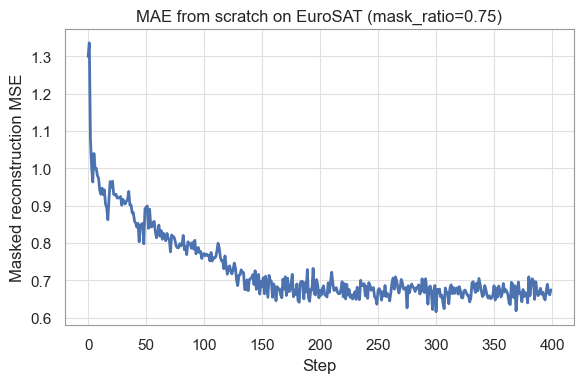

In [10]:
MASK_RATIO = 0.75

# 400 steps rather than ~100, matching Notebook 1: from a random start the encoder needs
# noticeably more updates before the embedding space shows any class structure at all.
NUM_STEPS = 400

mae_model = MAEModel(build_vit_s8()).to(device)
optimizer = optim.AdamW(mae_model.parameters(), lr=1.5e-3, weight_decay=0.05)

loss_history = []
data_iter = iter(train_loader)
mae_model.train()

for step in tqdm(range(NUM_STEPS)):
    try:
        imgs, _ = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        imgs, _ = next(data_iter)
    imgs = imgs.to(device)

    pred, mask = mae_model(imgs, mask_ratio=MASK_RATIO)
    loss = mae_reconstruction_loss(pred, imgs, mask)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

# Keep these weights: the final figure compares them against the long offline checkpoint, and
# Notebook 4 can load the same file.
NOTEBOOK_CKPT = os.path.join(CHECKPOINT_PATH, "mae_vit_s8_notebook.pt")
torch.save(mae_model.encoder.state_dict(), NOTEBOOK_CKPT)
print(f"Saved this notebook's encoder to {NOTEBOOK_CKPT}")

plot_curve(loss_history, xlabel="Step", ylabel="Masked reconstruction MSE",
           title=f"MAE from scratch on EuroSAT (mask_ratio={MASK_RATIO})")


## Loading the pretrained encoder

In [11]:
pretrained_mae = MAEModel(build_vit_s8()).to(device)
found = try_load_checkpoint(pretrained_mae.encoder, CHECKPOINT_PATH, "mae_vit_s8.pt", device)
if not found:
    print("Falling back to the briefly-trained model from the live-training cell above.")
    pretrained_mae = mae_model

pretrained_mae.eval()

Found pretrained model at ../../artifacts/remote_sensing/checkpoints\mae_vit_s8.pt, loading...


MAEModel(
  (encoder): ViTEncoder(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 384, kernel_size=(8, 8), stride=(8, 8))
    )
    (blocks): ModuleList(
      (0-5): 6 x TransformerBlock(
        (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=384, out_features=384, bias=True)
        )
        (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=1536, out_features=384, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
  )
  (decoder_embed): Linear(in_features=384, out_features=192, bias=True)
  (decoder_blocks): ModuleList(
    (0-1): 2 x Transfo

## The MAE signature visual: masked -> reconstructed -> original

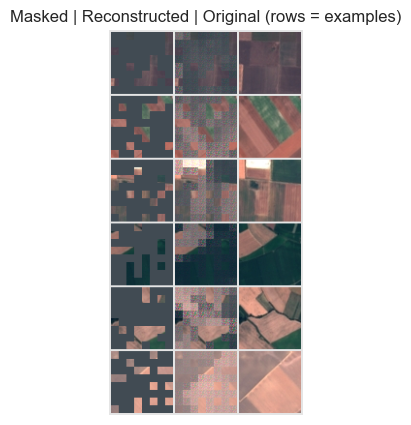

In [12]:
@torch.no_grad()
def visualize_reconstruction(model, imgs, mask_ratio=0.75, norm_pix=True):
    pred, mask = model(imgs, mask_ratio=mask_ratio)  # pred: (B,N,patch_dim), mask: (B,N)

    target = patchify(imgs)

    # The model is trained to predict per-patch STANDARDIZED pixels (norm_pix), so `pred` lives
    # in that normalized space. To display it we map each predicted patch back to pixel space
    # using that patch's own mean/std (the same statistics the loss standardized the target by).
    if norm_pix:
        mean = target.mean(dim=-1, keepdim=True)
        std = (target.var(dim=-1, keepdim=True) + 1.0e-6).sqrt()
        pred = pred * std + mean

    # Masked view: keep visible patches, zero out masked ones
    masked_patches = target.clone()
    masked_patches[mask.bool()] = 0.0
    masked_imgs = unpatchify(masked_patches)

    # Reconstruction: predicted values at masked positions, original at visible positions
    recon_patches = torch.where(mask.unsqueeze(-1).bool(), pred, target)
    recon_imgs = unpatchify(recon_patches)

    return masked_imgs, recon_imgs


sample_imgs = torch.stack([full_dataset[i][0] for i in test_idx[:6]]).to(device)
masked_imgs, recon_imgs = visualize_reconstruction(pretrained_mae, sample_imgs, mask_ratio=MASK_RATIO)

rows = []
for i in range(6):
    rows.append(denormalize(masked_imgs[i].cpu(), EUROSAT_MEAN, EUROSAT_STD))
    rows.append(denormalize(recon_imgs[i].cpu(), EUROSAT_MEAN, EUROSAT_STD))
    rows.append(denormalize(sample_imgs[i].cpu(), EUROSAT_MEAN, EUROSAT_STD))
grid_imgs = torch.stack(rows, dim=0)

show_image_grid(grid_imgs, nrow=3, title="Masked | Reconstructed | Original (rows = examples)")

## The shortcut failure mode: low mask ratio -> trivial interpolation

<div class="alert alert-info">

**Why 60-75% and not, say, 15%?** If too few patches are masked, the model can solve the
reconstruction task by smoothing/interpolating from neighboring visible patches without
learning anything about global structure or semantics, a shortcut. Below, compare
reconstructions at a much lower mask ratio: they still look "reasonable" (low pixel error)
even though the underlying representation task was never forced to be hard.

</div>

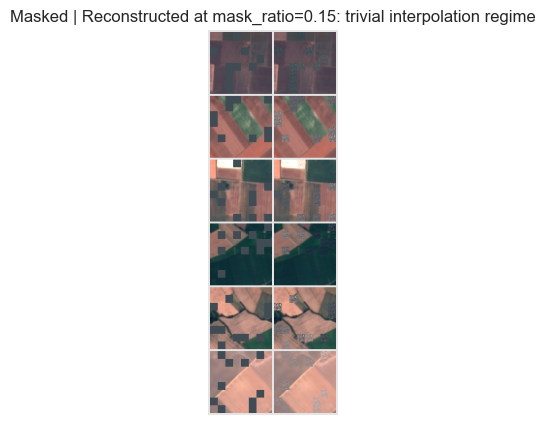

In [13]:
LOW_MASK_RATIO = 0.15

masked_imgs_low, recon_imgs_low = visualize_reconstruction(pretrained_mae, sample_imgs, mask_ratio=LOW_MASK_RATIO)

rows = []
for i in range(6):
    rows.append(denormalize(masked_imgs_low[i].cpu(), EUROSAT_MEAN, EUROSAT_STD))
    rows.append(denormalize(recon_imgs_low[i].cpu(), EUROSAT_MEAN, EUROSAT_STD))
grid_imgs_low = torch.stack(rows, dim=0)

show_image_grid(grid_imgs_low, nrow=2,
                 title=f"Masked | Reconstructed at mask_ratio={LOW_MASK_RATIO}: trivial interpolation regime")

## Embedding space: two encoders, one architecture

Following the same comparison as Notebook 1, we encode the EuroSAT **test split** with two
frozen ViT-S/8 encoders and reduce the embeddings to 2D with identical t-SNE settings,
coloring by the true class (never seen during pretraining):

1. **This notebook's MAE.** The 400-step live run on EuroSAT (`mae_model`), from random init.
2. **Offline MAE.** `mae_vit_s8.pt`: the same MAE mechanism, the same random start, trained for
   10,000 steps on the Sentinel-2 / SeCo corpus.

This is a controlled comparison: same architecture, same pretext task, same initialization.
The only variable is the pretraining budget.

<div class="alert alert-info">

**Both panels are mean-pooled over the patch tokens**, not read from `[CLS]`. MAE never
supervises `[CLS]` (its loss lives entirely on patch tokens), so a `[CLS]` readout would
understate both encoders and make the comparison unfair. See `forward_features(pool=...)`.

</div>


embeddings: (5400, 384) (same for both)


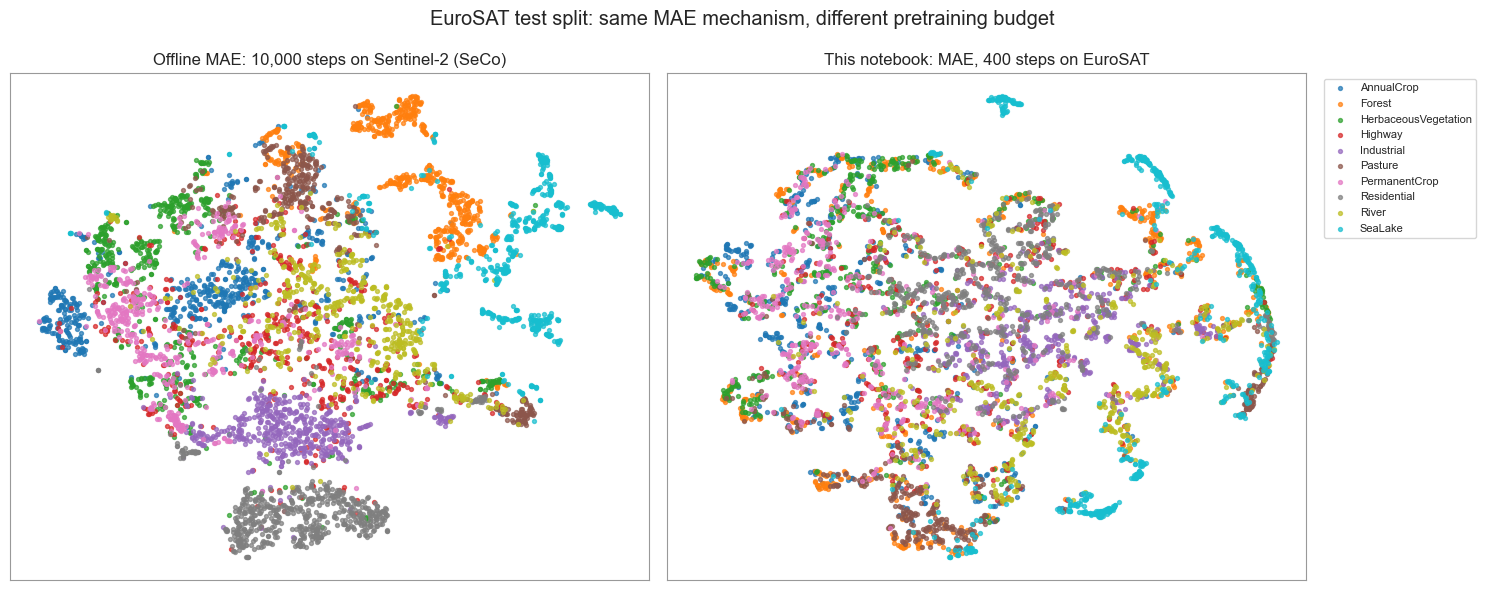

In [14]:
from sklearn.manifold import TSNE

# EuroSAT test split, deterministic transform, labels kept only for coloring.
tsne_test_loader = data.DataLoader(
    data.Subset(full_dataset, test_idx), batch_size=256, shuffle=False, num_workers=0
)


@torch.no_grad()
def encode_meanpool(encoder, loader, desc):
    """Frozen encoder -> (N, embed_dim) mean-pooled patch embeddings + (N,) labels."""
    encoder.eval()
    feats, labels = [], []
    for imgs, lab in tqdm(loader, desc=desc, leave=False):
        feats.append(encoder.forward_features(imgs.to(device), pool="mean").cpu())
        labels.append(lab)
    return torch.cat(feats).numpy(), torch.cat(labels).numpy()


# 1. This notebook's briefly-trained MAE encoder (from the live-training cell).
# 2. The offline MAE encoder loaded from mae_vit_s8.pt.
feats_live, all_labels = encode_meanpool(mae_model.encoder, tsne_test_loader,
                                         f"MAE {NUM_STEPS} steps")
feats_offline, _       = encode_meanpool(pretrained_mae.encoder, tsne_test_loader,
                                         "MAE offline (SeCo)")

print("embeddings:", feats_live.shape, "(same for both)")

# Identical t-SNE settings for both panels, so they are directly comparable.
tsne_kw = dict(n_components=2, random_state=42, init="pca", perplexity=30)
panels = [
    (TSNE(**tsne_kw).fit_transform(feats_offline), "Offline MAE: 10,000 steps on Sentinel-2 (SeCo)"),
    (TSNE(**tsne_kw).fit_transform(feats_live),    f"This notebook: MAE, {NUM_STEPS} steps on EuroSAT"),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
cmap = plt.get_cmap("tab10")
for ax, (emb, panel_title) in zip(axes, panels):
    for cls_idx, cls_name in enumerate(EUROSAT_CLASSES):
        m = all_labels == cls_idx
        ax.scatter(emb[m, 0], emb[m, 1], s=8, color=cmap(cls_idx % 10), label=cls_name, alpha=0.7)
    ax.set_title(panel_title)
    ax.set_xticks([]); ax.set_yticks([])

axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.suptitle("EuroSAT test split: same MAE mechanism, different pretraining budget")
plt.tight_layout()
plt.show()
plt.close()


**Reading the two panels.** Same architecture, same masked-reconstruction objective, same
random initialization, same pooling and the same t-SNE settings. The only difference is the
pretraining budget: 10,000 steps on SeCo versus 400 steps here.

Expect the 400-step panel to look largely unstructured. That is the honest result for a run
whose purpose is to show the loss falling, and it is worth seeing: masked reconstruction gives
a usable representation only after substantially more optimization than a tutorial cell can
afford. The offline panel should show some classes (SeaLake, Residential, Forest) pulling
apart, with several land-cover types still entangled in the middle.


### References

- He, K., Chen, X., Xie, S., Li, Y., Dollar, P., & Girshick, R. (2022). *Masked Autoencoders
  Are Scalable Vision Learners (MAE).* CVPR.
- Cong, Y. et al. (2022). *SatMAE: Pre-training Transformers for Temporal and Multi-Spectral
  Satellite Imagery.* NeurIPS.
- Reed, C. J. et al. (2023). *Scale-MAE: A Scale-Aware Masked Autoencoder for Multiscale
  Geospatial Representation Learning.* ICCV.